In [1]:
import pandas as pd

df = pd.read_csv("products.csv")

df.head()

,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


In [2]:
print("Broj redova i kolona:", df.shape)

print("\nNazivi kolona:")
print(df.columns)

print("\nPrazne vrednosti:")
print(df.isnull().sum())

Broj redova i kolona: (35311, 8)

Nazivi kolona:
Index(['product ID', 'Product Title', 'Merchant ID', ' Category Label',
       '_Product Code', 'Number_of_Views', 'Merchant Rating',
       ' Listing Date  '],
      dtype='str')

Prazne vrednosti:
product ID           0
Product Title      172
Merchant ID          0
 Category Label     44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
 Listing Date       59
dtype: int64


In [3]:
print("Broj proizvoda po kategoriji:")
print(df[" Category Label"].value_counts())

Broj proizvoda po kategoriji:
 Category Label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64


In [4]:
df = df.dropna(subset=["Product Title", " Category Label"])

print("Broj redova nakon čišćenja:", len(df))

Broj redova nakon čišćenja: 35096


In [5]:
print(df[["Product Title", " Category Label"]].head(10))

                                       Product Title  Category Label
0                    apple iphone 8 plus 64gb silver   Mobile Phones
1                apple iphone 8 plus 64 gb spacegrau   Mobile Phones
2  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...   Mobile Phones
3                apple iphone 8 plus 64gb space grey   Mobile Phones
4  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...   Mobile Phones
5  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...   Mobile Phones
6               apple iphone 8 plus 64 gb space grey   Mobile Phones
7                apple iphone 8 plus 64gb space grey   Mobile Phones
8                apple iphone 8 plus 64gb space grey   Mobile Phones
9                apple iphone 8 plus 64gb space grey   Mobile Phones


In [6]:
X = df["Product Title"]
y = df[" Category Label"]

print("X - nazivi proizvoda:", len(X))
print("y - kategorije:", len(y))

X - nazivi proizvoda: 35096
y - kategorije: 35096


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Broj podataka za treniranje:", len(X_train))
print("Broj podataka za testiranje:", len(X_test))

Broj podataka za treniranje: 28076
Broj podataka za testiranje: 7020


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

model1 = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", LogisticRegression(max_iter=1500))
])

model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

accuracy1 = accuracy_score(y_test, y_pred1)

print("Tačnost prvog modela:", accuracy1)

Tačnost prvog modela: 0.9482905982905983


In [9]:
from sklearn.naive_bayes import MultinomialNB

model2 = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", MultinomialNB())
])

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

accuracy2 = accuracy_score(y_test, y_pred2)

print("Tačnost drugog modela:", accuracy2)

Tačnost drugog modela: 0.9304843304843304


In [10]:
print("Logistic Regression:", accuracy1)
print("Naive Bayes:", accuracy2)

if accuracy1 > accuracy2:
    print("Bolji model je Logistic Regression")
else:
    print("Bolji model je Naive Bayes")

Logistic Regression: 0.9482905982905983
Naive Bayes: 0.9304843304843304
Bolji model je Logistic Regression


In [15]:
from sklearn.metrics import classification_report

print("Rezultati za Logistic Regression:")
print(classification_report(y_test, y_pred1))

Rezultati za Logistic Regression:
                  precision    recall  f1-score   support

             CPU       0.00      0.00      0.00        14
            CPUs       0.98      1.00      0.99       726
 Digital Cameras       0.99      0.99      0.99       535
     Dishwashers       0.91      0.95      0.93       684
        Freezers       0.99      0.86      0.92       422
 Fridge Freezers       0.95      0.93      0.94      1087
         Fridges       0.84      0.92      0.88       702
      Microwaves       0.99      0.95      0.97       464
    Mobile Phone       0.00      0.00      0.00        17
   Mobile Phones       0.95      0.98      0.97       795
             TVs       0.97      0.98      0.98       724
Washing Machines       0.95      0.96      0.96       821
          fridge       0.00      0.00      0.00        29

        accuracy                           0.95      7020
       macro avg       0.73      0.73      0.73      7020
    weighted avg       0.94      0.9

C:\Users\Windows10\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Windows10\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Windows10\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

In [16]:
print("Rezultati za Naive Bayes:")
print(classification_report(y_test, y_pred2))

Rezultati za Naive Bayes:
                  precision    recall  f1-score   support

             CPU       0.00      0.00      0.00        14
            CPUs       0.98      1.00      0.99       726
 Digital Cameras       0.99      1.00      1.00       535
     Dishwashers       0.99      0.96      0.97       684
        Freezers       1.00      0.53      0.69       422
 Fridge Freezers       0.76      0.98      0.86      1087
         Fridges       0.89      0.82      0.85       702
      Microwaves       0.99      0.97      0.98       464
    Mobile Phone       0.00      0.00      0.00        17
   Mobile Phones       0.98      0.99      0.98       795
             TVs       0.98      0.99      0.99       724
Washing Machines       0.97      0.98      0.97       821
          fridge       0.00      0.00      0.00        29

        accuracy                           0.93      7020
       macro avg       0.73      0.71      0.71      7020
    weighted avg       0.93      0.93      0

C:\Users\Windows10\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Windows10\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Windows10\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

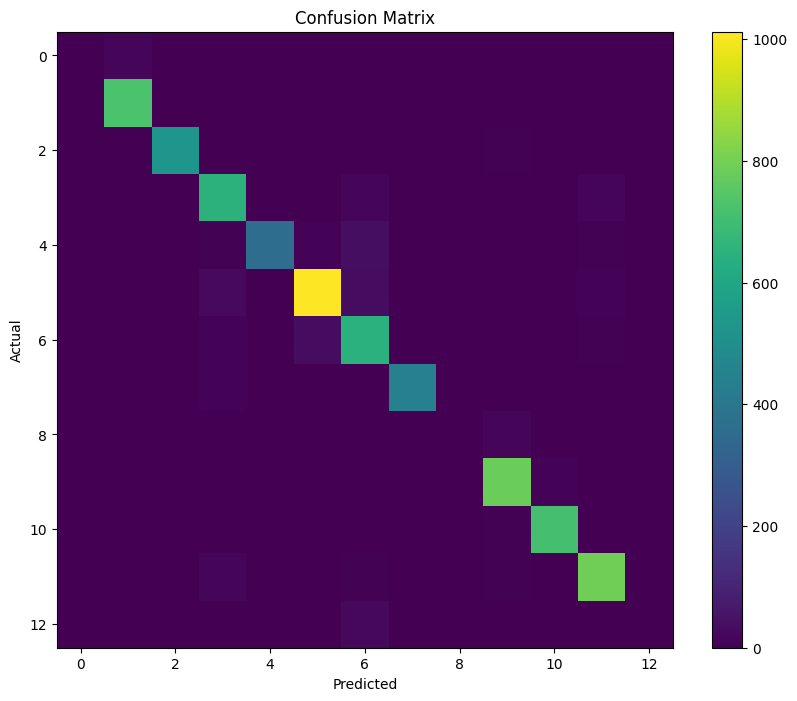

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred1)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [18]:
if accuracy1 > accuracy2:
    best_model = model1
    print("Izabran je Logistic Regression model.")
else:
    best_model = model2
    print("Izabran je Naive Bayes model.")

Izabran je Logistic Regression model.


In [19]:
import pickle

with open("product_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("Model je sacuvan.")

Model je sacuvan.


In [20]:
test_products = [
    "iphone 7 32gb gold",
    "olympus e m10 mark iii geh use silber",
    "kenwood k20mss15 solo",
    "bosch wap28390gb 8kg 1400 spin",
    "bosch serie 4 kgv39vl31g",
    "smeg sbs8004po"
]

for product in test_products:
    prediction = best_model.predict([product])
    print(product, "->", prediction[0])

iphone 7 32gb gold -> Mobile Phones
olympus e m10 mark iii geh use silber -> Digital Cameras
kenwood k20mss15 solo -> Microwaves
bosch wap28390gb 8kg 1400 spin -> Washing Machines
bosch serie 4 kgv39vl31g -> Dishwashers
smeg sbs8004po -> Fridges
